In [ ]:
!pip install lifelines


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=b32bd848cb0531fb9cf05b7a928bcf1536bb176c196ed64248f5d1a3912f2423
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve

from lifelines import KaplanMeierFitter, CoxPHFitter


Load Dataset

In [ ]:
df = pd.read_csv("Breast Cancer METABRIC.csv")

print(df.shape)
df.head()


(2509, 34)


,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,...,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


Renaming Coloums(Important columns)

In [ ]:
df = df.rename(columns={
    'Overall Survival (Months)': 'overall_survival_months',
    'Overall Survival Status': 'overall_survival_status'
})


Convert Survival Status

In [ ]:
# Map categorical survival status to numeric
df['overall_survival_status'] = df['overall_survival_status'].map({
    'Living': 0,
    'Deceased': 1
})


Convert survival Months to numeric

In [ ]:
df['overall_survival_months'] = pd.to_numeric(
    df['overall_survival_months'], errors='coerce'
)


Convert Months to Years

In [ ]:
df['survival_years'] = df['overall_survival_months'] / 12


Clean Dataset (NO NaNs / NO Empty Arrays)

In [ ]:
df = df.dropna(subset=['survival_years', 'overall_survival_status'])

df = df[
    (df['survival_years'] > 0) &
    (df['overall_survival_status'].isin([0,1]))
]

print(df.shape)


(1980, 35)


Kaplan–Meier Survival Curve

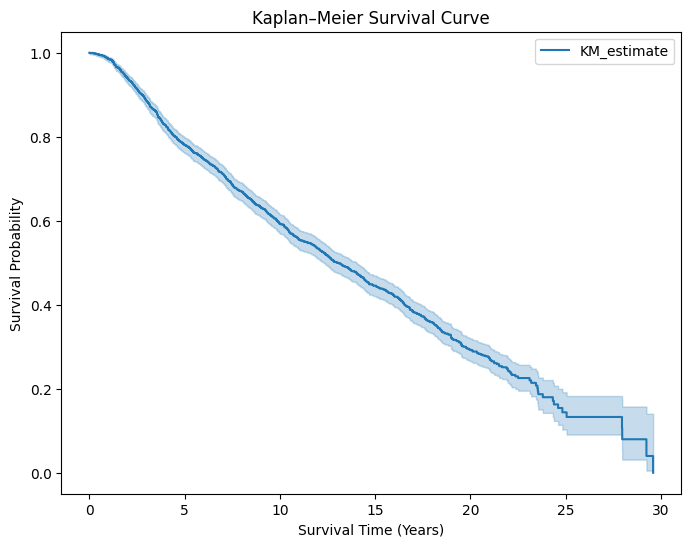

In [ ]:
kmf = KaplanMeierFitter()

kmf.fit(
    durations=df['survival_years'].values,
    event_observed=df['overall_survival_status'].values
)

plt.figure(figsize=(8,6))
kmf.plot_survival_function()
plt.title("Kaplan–Meier Survival Curve")
plt.xlabel("Survival Time (Years)")
plt.ylabel("Survival Probability")
plt.show()


Cox Proportional Hazards Model

In [ ]:
cox_df = df[['survival_years', 'overall_survival_status',
             'Age at Diagnosis', 'Tumor Size', 'Lymph nodes examined positive']]

cox_df = cox_df.dropna()

cph = CoxPHFitter()
cph.fit(
    cox_df,
    duration_col='survival_years',
    event_col='overall_survival_status'
)

cph.print_summary()


<lifelines.CoxPHFitter: fitted with 1885 total observations, 794 right-censored observations>
             duration col = 'survival_years'
                event col = 'overall_survival_status'
      baseline estimation = breslow
   number of observations = 1885
number of events observed = 1091
   partial log-likelihood = -7279.43
         time fit was run = 2025-12-29 06:27:55 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
Age at Diagnosis               0.03      1.04      0.00            0.03            0.04                1.03                1.04
Tumor Size                     0.01      1.01      0.00            0.01            0.01                1.01                1.01
Lymph nodes examined positive  0.06      1.06      0.01            0.05            0.07                1.05                1.07

                               cmp to     z      p  -log2(p)
covariate                                                   
Age at Diagnosis                 0.00 13.09 <0.005    127.58
Tumor Size                       0.00  7.41 <0.005     42.80
Lymph nodes examined positive    0.00 11.09 <0.005     92.59
---
Concordance = 0.64
Partial AIC = 14564.85
log-likelihood ratio test = 337.07 on 3 df
-log2(p) of ll-ratio test = 239.27

MACHINE LEARNING – 10 YEAR RISK PREDICTION

Target Variable

In [ ]:
# Target: died within 10 years
df['death_within_10_years'] = np.where(
    (df['survival_years'] <= 10) & (df['overall_survival_status'] == 1),
    1, 0
)


Feature Selection

In [ ]:
features = [
    'Age at Diagnosis',
    'Tumor Size',
    'Lymph nodes examined positive'
]

X = df[features].dropna()
y = df.loc[X.index, 'death_within_10_years']


Train–Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))



Logistic Regression Accuracy: 0.6790450928381963


Support Vector Machine (SVM)

In [ ]:
svm = SVC(probability=True)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:,1]

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))


SVM Accuracy: 0.6790450928381963


Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Accuracy: 0.5862068965517241


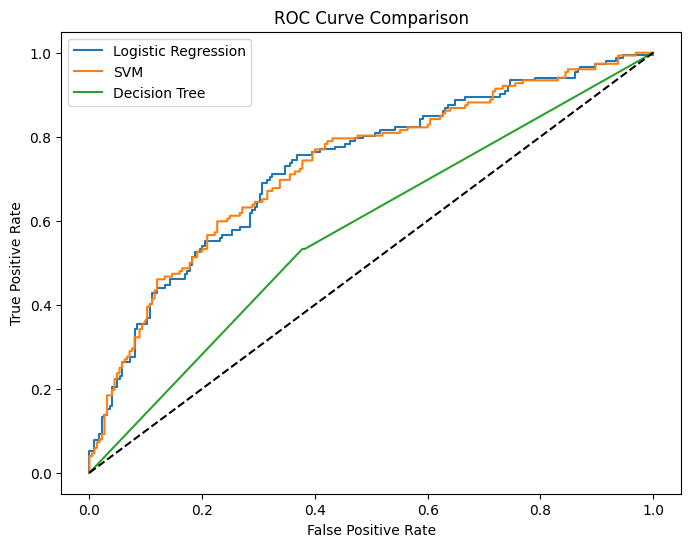

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_svm, tpr_svm, label='SVM')
plt.plot(fpr_dt, tpr_dt, label='Decision Tree')
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


This project uses survival analysis and machine learning to predict 10-year mortality risk in breast cancer patients and compare multiple models using ROC curves.